In [3]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.coordinates import SkyCoord

# Enable 3D plotting
from mpl_toolkits.mplot3d import Axes3D

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [4]:
# 1. Fetch the Angular Coordinates (RA and Dec)
# Alpha Centauri A (2nd closest star)
star_A = SkyCoord.from_name("Alpha Centauri A")

# Alpha Centauri B (3rd closest star)
star_B = SkyCoord.from_name("Alpha Centauri B")

# 2. Add the Radial Distance (Parallax Distance)
# We manually attach distance data (approx 4.37 light years for both)
# In a real large-scale app, we would query the 'Gaia' catalog for this.
star_A_3d = SkyCoord(ra=star_A.ra, dec=star_A.dec, distance=4.37 * u.lyr)
star_B_3d = SkyCoord(ra=star_B.ra, dec=star_B.dec, distance=4.37 * u.lyr)

print(f"Star A Coordinates: {star_A_3d}")
print(f"Star B Coordinates: {star_B_3d}")# Calculate the 3D separation


Star A Coordinates: <SkyCoord (ICRS): (ra, dec, distance) in (deg, deg, lyr)
    (219.90205833, -60.83399269, 4.37)>
Star B Coordinates: <SkyCoord (ICRS): (ra, dec, distance) in (deg, deg, lyr)
    (219.89609629, -60.83752757, 4.37)>


In [5]:
# Calculate the 3D separation
separation = star_A_3d.separation_3d(star_B_3d)

print(f"Distance in Light Years: {separation.to(u.lyr):.5f}")
print(f"Distance in AU: {separation.to(u.au):.2f}")

Distance in Light Years: 0.00035 lyr
Distance in AU: 22.07 AU


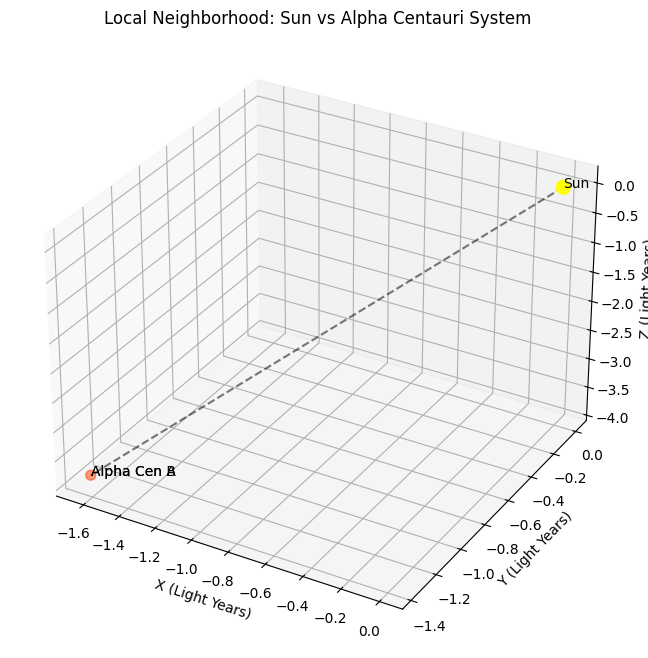

In [7]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Convert to Cartesian (x, y, z) for plotting
# We use .cartesian.xyz.value to get raw numbers for matplotlib
x = [0, star_A_3d.cartesian.x.value, star_B_3d.cartesian.x.value]
y = [0, star_A_3d.cartesian.y.value, star_B_3d.cartesian.y.value]
z = [0, star_A_3d.cartesian.z.value, star_B_3d.cartesian.z.value]

# Plot the points
ax.scatter(x, y, z, c=['yellow', 'red', 'orange'], s=[100, 50, 50])

# Label them
labels = ['Sun', 'Alpha Cen A', 'Alpha Cen B']
for i, txt in enumerate(labels):
    ax.text(x[i], y[i], z[i], txt)

# Draw lines from Sun to stars to visualize the vectors
ax.plot([0, x[1]], [0, y[1]], [0, z[1]], 'k--', alpha=0.3)
ax.plot([0, x[2]], [0, y[2]], [0, z[2]], 'k--', alpha=0.3)

ax.set_xlabel('X (Light Years)')
ax.set_ylabel('Y (Light Years)')
ax.set_zlabel('Z (Light Years)')
ax.set_title('Local Neighborhood: Sun vs Alpha Centauri System')

plt.show()